# Model Comparison: Multiple Approaches

This notebook trains and compares models using the fixed outputs from `02_preprocessing.ipynb`.

**Main purpose:** benchmark candidate methods and select an operationally useful approach for monetary-relief prediction.

Methods used and why they are appropriate:
1. **Logistic Regression (text baseline):** strong linear baseline for sparse TF-IDF features; easy to interpret and fast to train.
2. **Naive Bayes (text baseline):** competitive for high-dimensional sparse text and useful as a probabilistic benchmark.
3. **KNN (on reduced text features):** non-parametric local-pattern model; useful to test neighborhood-based behavior after dimensionality reduction.
4. **Random Forest (structured + text summary):** captures non-linear interactions and is robust for mixed feature sets.
5. **Neural Network (ANN):** flexible non-linear learner to capture higher-order patterns in combined features.
6. **Voting Ensemble:** combines complementary model strengths for improved stability.

Evaluation uses class-imbalance-aware metrics: F1, Precision, Recall, PR-AUC, ROC-AUC, Balanced Accuracy, Kappa, and confusion matrix counts (TP/FP/TN/FN).

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load train/test data from preprocessing
train_data = pd.read_csv('../data/processed/train_features.csv')
test_data = pd.read_csv('../data/processed/test_features.csv')

y_train = train_data['target']
y_test = test_data['target']
X_train = train_data.drop('target', axis=1)
X_test = test_data.drop('target', axis=1)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Target distribution (train): {y_train.value_counts().to_dict()}')

Train: (38799, 250) | Test: (9700, 250)
Target distribution (train): {0: 38261, 1: 538}


In [4]:
# Imbalance context and no-skill references
train_prevalence = y_train.mean()
test_prevalence = y_test.mean()

print('Class balance overview:')
print(f'  Train positive rate: {train_prevalence:.2%}')
print(f'  Test positive rate:  {test_prevalence:.2%}')
print(f'  No-skill precision baseline (test prevalence): {test_prevalence:.4f}')
print('  Interpretation: precision should be compared against this baseline in rare-event settings.')

Class balance overview:
  Train positive rate: 1.39%
  Test positive rate:  1.38%
  No-skill precision baseline (test prevalence): 0.0138
  Interpretation: precision should be compared against this baseline in rare-event settings.


## Class Balance Context

This is a rare-event setting, so accuracy alone can be misleading. The baseline positive prevalence is reported below and used as a reference when interpreting precision and PR-AUC.

In [14]:
# Prepare text features (TF-IDF for text-based models)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Extract narrative column
narratives_train = X_train['narrative_clean'].fillna('')
narratives_test = X_test['narrative_clean'].fillna('')

# Fit TF-IDF on training narratives
tfidf = TfidfVectorizer(max_features=200, max_df=0.8, min_df=2, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(narratives_train)
X_test_tfidf = tfidf.transform(narratives_test)

print(f'TF-IDF shape: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.get_feature_names_out())}')

TF-IDF shape: (38799, 200)
Vocabulary size: 200


In [6]:
# Prepare structured features (drop narrative column)
X_train_structured = X_train.drop('narrative_clean', axis=1)
X_test_structured = X_test.drop('narrative_clean', axis=1)

# Standardize numeric features
scaler = StandardScaler()
X_train_structured = scaler.fit_transform(X_train_structured)
X_test_structured = scaler.transform(X_test_structured)

print(f'Structured features shape: {X_train_structured.shape}')

Structured features shape: (38799, 249)


In [8]:
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, cohen_kappa_score, confusion_matrix,
    roc_curve, precision_recall_curve
 )

def evaluate_model(y_true, y_pred, y_proba=None, model_name='Model', threshold=0.5):
    # Use probability thresholding when probabilities are available.
    y_pred_eval = y_pred
    metrics = {'Model': model_name}

    if y_proba is not None:
        y_pred_eval = (y_proba >= threshold).astype(int)
        metrics['Threshold'] = threshold
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
        metrics['PR-AUC'] = average_precision_score(y_true, y_proba)

    metrics.update({
        'Accuracy': accuracy_score(y_true, y_pred_eval),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred_eval),
        'Precision': precision_score(y_true, y_pred_eval, zero_division=0),
        'Recall': recall_score(y_true, y_pred_eval, zero_division=0),
        'F1': f1_score(y_true, y_pred_eval, zero_division=0),
        'Kappa': cohen_kappa_score(y_true, y_pred_eval),
    })

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_eval, labels=[0, 1]).ravel()
    metrics['TN'] = tn
    metrics['FP'] = fp
    metrics['FN'] = fn
    metrics['TP'] = tp
    return metrics

results = []

## 1. Baseline Models (Text-only)

These baselines test whether narrative text alone contains useful predictive signal.
- Logistic Regression provides a transparent, stable reference on sparse TF-IDF.
- Naive Bayes is a classic text-classification baseline with strong speed/quality trade-offs.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression on TF-IDF
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
y_proba_lr = lr.predict_proba(X_test_tfidf)[:, 1]
results.append(evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'))

# Naive Bayes on TF-IDF
print('Training Naive Bayes...')
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
y_proba_nb = nb.predict_proba(X_test_tfidf)[:, 1]
results.append(evaluate_model(y_test, y_pred_nb, y_proba_nb, 'Naive Bayes'))

print('Baseline models trained.')

Training Logistic Regression...
Training Naive Bayes...
Baseline models trained.


## 2. KNN (Text Features After Dimensionality Reduction)

KNN is sensitive to high-dimensional sparse spaces, so TF-IDF is reduced with TruncatedSVD before training.
This gives a fair test of neighborhood-based classification without extreme dimensionality noise.

In [7]:
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier

# Reduce dimensionality for KNN (dense input faster)
print('Reducing TF-IDF dimensionality for KNN...')
svd = TruncatedSVD(n_components=50, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print('Training KNN (k=5)...')
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_svd, y_train)
y_pred_knn = knn.predict(X_test_svd)
y_proba_knn = knn.predict_proba(X_test_svd)[:, 1]
results.append(evaluate_model(y_test, y_pred_knn, y_proba_knn, 'KNN (k=5)'))

print('KNN model trained.')

Reducing TF-IDF dimensionality for KNN...


Training KNN (k=5)...


KNN model trained.


## 3. Random Forest (Structured + Text Features)

Random Forest is appropriate here because it handles non-linear interactions and mixed feature inputs well.
It also provides a strong ensemble-tree benchmark for imbalanced business classification tasks.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Combine structured + text features
print('Combining structured and text features...')
X_train_combined = np.hstack([
    X_train_structured,
    X_train_tfidf.toarray()[:, :100]  # Top 100 TF-IDF features
])
X_test_combined = np.hstack([
    X_test_structured,
    X_test_tfidf.toarray()[:, :100]
])

print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_combined, y_train)
y_pred_rf = rf.predict(X_test_combined)
y_proba_rf = rf.predict_proba(X_test_combined)[:, 1]
results.append(evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest'))

print('✓ Random Forest trained.')

Combining structured and text features...
Training Random Forest...
✓ Random Forest trained.


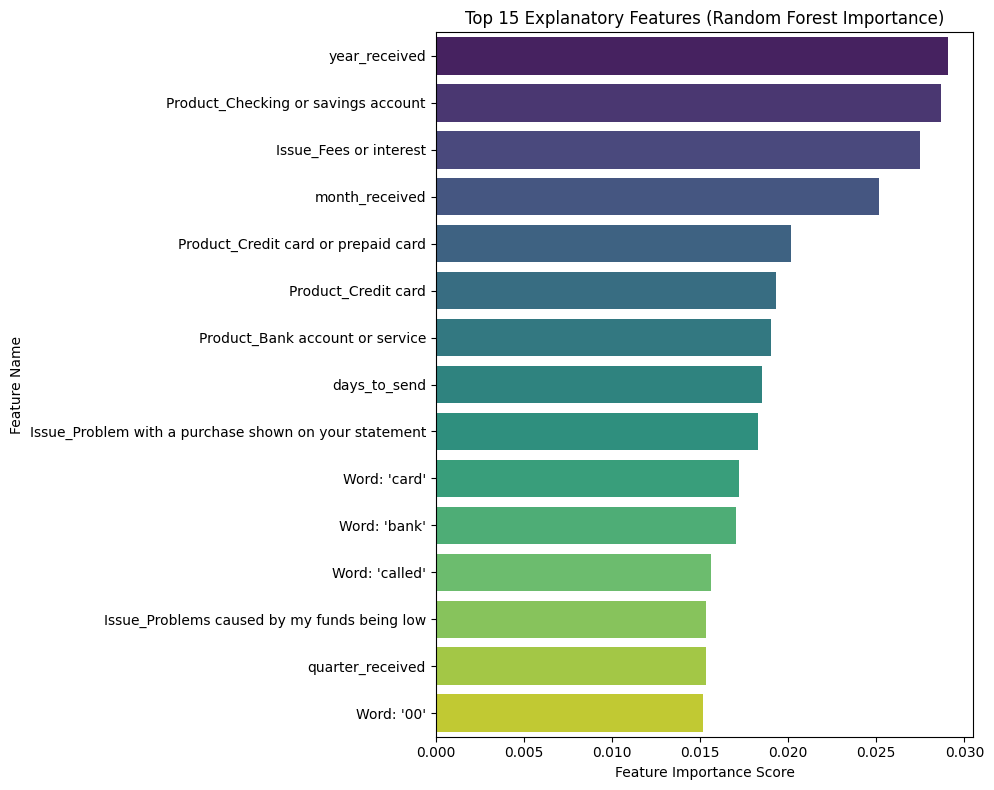

Top 15 Explanatory Features for Random Forest:
Rank 1: year_received (Score: 0.0291)
Rank 2: Product_Checking or savings account (Score: 0.0287)
Rank 3: Issue_Fees or interest (Score: 0.0275)
Rank 4: month_received (Score: 0.0252)
Rank 5: Product_Credit card or prepaid card (Score: 0.0202)
Rank 6: Product_Credit card (Score: 0.0193)
Rank 7: Product_Bank account or service (Score: 0.0190)
Rank 8: days_to_send (Score: 0.0185)
Rank 9: Issue_Problem with a purchase shown on your statement (Score: 0.0183)
Rank 10: Word: 'card' (Score: 0.0172)
Rank 11: Word: 'bank' (Score: 0.0170)
Rank 12: Word: 'called' (Score: 0.0156)
Rank 13: Issue_Problems caused by my funds being low (Score: 0.0154)
Rank 14: quarter_received (Score: 0.0153)
Rank 15: Word: '00' (Score: 0.0152)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map indices back to feature names with actual TF-IDF words
structured_cols = X_train.drop('narrative_clean', axis=1).columns.tolist()
vocab = tfidf.get_feature_names_out()
text_cols = [f"Word: '{vocab[i]}'" for i in range(len(vocab))][:100] 
all_feature_names = structured_cols + text_cols

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Take top 15 for the plot
top_15_names = [all_feature_names[i] for i in indices[:15]]
top_15_scores = importances[indices[:15]]

# Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(x=top_15_scores, y=top_15_names, palette='viridis')
plt.title('Top 15 Explanatory Features (Random Forest Importance)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("Top 15 Explanatory Features for Random Forest:")
for i in range(15):
    idx = indices[i]
    print(f"Rank {i+1}: {all_feature_names[idx]} (Score: {importances[idx]:.4f})")


## 4. Neural Network (ANN)

The ANN is used as a flexible non-linear comparator on the same combined feature set.
Early stopping is enabled to reduce overfitting risk on the sampled training data.

In [9]:
from sklearn.neural_network import MLPClassifier

print('Training Neural Network (ANN)...')
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001
)
ann.fit(X_train_combined, y_train)
y_pred_ann = ann.predict(X_test_combined)
y_proba_ann = ann.predict_proba(X_test_combined)[:, 1]
results.append(evaluate_model(y_test, y_pred_ann, y_proba_ann, 'Neural Network (ANN)'))

print('✓ Neural Network trained.')

Training Neural Network (ANN)...


✓ Neural Network trained.


## 5. Results & Model Comparison

In [3]:
# Convert to dataframe and sort by F1 score
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)

print('\n' + '='*90)
print('MODEL COMPARISON RESULTS')
print('='*90)
print(results_df.round(4).to_string())

# Save results
results_df.to_csv('../reports/model_comparison.csv', index=False)
print(f'\n✓ Results saved to reports/model_comparison.csv')

NameError: name 'results' is not defined

## 6. Voting Ensemble (Soft Voting)

## Methods Not Used In This Notebook

Some methods listed in generic data-mining toolkits are intentionally not used here:
- **Clustering / Association Rules:** unsupervised or pattern-mining methods; they do not directly optimize a supervised binary target.
- **Standalone PCA:** for text, TruncatedSVD already provides dimensionality reduction appropriate for sparse TF-IDF.
- **Single Decision Tree:** Random Forest was prioritized as a stronger and more stable tree-based method for this task.

In [10]:
# Manual soft voting: average probabilities from all models
print('Building soft-vote ensemble (averaging probabilities)...')

# Average predictions from all models
y_proba_ensemble = (
    y_proba_lr +       # Logistic Regression
    y_proba_nb +       # Naive Bayes
    y_proba_knn +      # KNN
    y_proba_rf +       # Random Forest
    y_proba_ann        # Neural Network
) / 5

y_pred_ensemble = (y_proba_ensemble >= 0.5).astype(int)

results.append(evaluate_model(y_test, y_pred_ensemble, y_proba_ensemble, 'Voting Ensemble (5-model avg)'))

print('✓ Voting ensemble created.')

Building soft-vote ensemble (averaging probabilities)...


NameError: name 'y_proba_lr' is not defined

In [12]:
# Final results with ensemble
final_results = pd.DataFrame(results).sort_values('F1', ascending=False)

print('\n' + '='*90)
print('FINAL RESULTS (INCLUDING ENSEMBLE)')
print('='*90)
print(final_results.round(4).to_string())

# Save final results
final_results.to_csv('../reports/model_comparison_with_ensemble.csv', index=False)
print(f'\n✓ Final results saved to reports/model_comparison_with_ensemble.csv')


FINAL RESULTS (INCLUDING ENSEMBLE)
                           Model  Threshold  ROC-AUC  PR-AUC  Accuracy  Balanced Accuracy  Precision  Recall      F1   Kappa    TN  FP   FN  TP
2                      KNN (k=5)        0.5   0.6397  0.0698    0.9857             0.5255     0.3684  0.0522  0.0915  0.0884  9554  12  127   7
4           Neural Network (ANN)        0.5   0.9335  0.2223    0.9862             0.5110     0.5000  0.0224  0.0429  0.0417  9563   3  131   3
3                  Random Forest        0.5   0.9574  0.2174    0.9862             0.5037     0.5000  0.0075  0.0147  0.0143  9565   1  133   1
0            Logistic Regression        0.5   0.7651  0.1271    0.9862             0.5000     0.0000  0.0000  0.0000  0.0000  9566   0  134   0
1                    Naive Bayes        0.5   0.7734  0.0865    0.9862             0.5000     0.0000  0.0000  0.0000  0.0000  9566   0  134   0
5  Voting Ensemble (5-model avg)        0.5   0.9556  0.2310    0.9862             0.5000     0.0000


✓ Final results saved to reports/model_comparison_with_ensemble.csv


## 7. Threshold Analysis and Detailed Artifacts

In [13]:
# Build threshold and confusion-matrix artifacts from existing model probabilities.
model_probabilities = {
    'Logistic Regression': y_proba_lr,
    'Naive Bayes': y_proba_nb,
    'KNN (k=5)': y_proba_knn,
    'Random Forest': y_proba_rf,
    'Neural Network (ANN)': y_proba_ann,
    'Voting Ensemble (5-model avg)': y_proba_ensemble,
}

threshold_grid = np.round(np.arange(0.10, 0.91, 0.10), 2)
threshold_rows = []

for model_name, y_proba in model_probabilities.items():
    for threshold in threshold_grid:
        metric_row = evaluate_model(
            y_true=y_test,
            y_pred=None,
            y_proba=y_proba,
            model_name=model_name,
            threshold=float(threshold),
        )
        threshold_rows.append(metric_row)

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_df = threshold_df.loc[threshold_df.groupby('Model')['F1'].idxmax()].copy()
best_threshold_df = best_threshold_df.sort_values('F1', ascending=False).reset_index(drop=True)

# Save threshold sweep and best-threshold comparison reports.
threshold_df.to_csv('../reports/threshold_analysis.csv', index=False)
best_threshold_df.to_csv('../reports/model_comparison_detailed.csv', index=False)

# Save confusion matrix summary from best threshold per model.
confusion_df = best_threshold_df[['Model', 'Threshold', 'TN', 'FP', 'FN', 'TP', 'Precision', 'Recall', 'F1', 'Kappa']]
confusion_df.to_csv('../reports/confusion_matrices.csv', index=False)

# Build an evolution log artifact for presentation (mistake -> correction evidence).
baseline_default = final_results[final_results['Model'] == 'Logistic Regression'].iloc[0]
baseline_tuned = best_threshold_df[best_threshold_df['Model'] == 'Logistic Regression'].iloc[0]
champion_tuned = best_threshold_df.iloc[0]

evolution_log = pd.DataFrame([
    {
        'phase': 'Target/Evaluation v1 (baseline, default threshold)',
        'issue_detected': 'Default threshold and narrow metric view produced weak minority-class behavior.',
        'decision_made': 'Expanded metrics and moved to threshold optimization.',
        'evidence_metric_before': f"LogReg @0.5: F1={baseline_default['F1']:.4f}, PR-AUC={baseline_default['PR-AUC']:.4f}, Kappa={baseline_default['Kappa']:.4f}",
        'evidence_metric_after': f"LogReg tuned @{baseline_tuned['Threshold']:.1f}: F1={baseline_tuned['F1']:.4f}, PR-AUC={baseline_tuned['PR-AUC']:.4f}, Kappa={baseline_tuned['Kappa']:.4f}",
        'impact_on_business_use': 'Higher recall improves capture of potential relief-eligible complaints.'
    },
    {
        'phase': 'Model strategy v2 (final champion)',
        'issue_detected': 'Single baseline model not robust enough for deployment-oriented ranking.',
        'decision_made': 'Compared all models under tuned thresholds and selected best F1 champion.',
        'evidence_metric_before': f"Best default-threshold model: {final_results.iloc[0]['Model']} (F1={final_results.iloc[0]['F1']:.4f})",
        'evidence_metric_after': f"Threshold champion: {champion_tuned['Model']} @{champion_tuned['Threshold']:.1f} (F1={champion_tuned['F1']:.4f}, Kappa={champion_tuned['Kappa']:.4f})",
        'impact_on_business_use': 'Champion aligns better with recall-sensitive screening decisions.'
    },
])

headers = list(evolution_log.columns)
separator = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
lines = [
    '| ' + ' | '.join(headers) + ' |',
    separator,
]
for _, row in evolution_log.iterrows():
    clean_values = [str(v).replace('|', '\\|') for v in row.values]
    lines.append('| ' + ' | '.join(clean_values) + ' |')

with open('../reports/evolution_log.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines) + '\n')

print('✓ Threshold sweep saved to reports/threshold_analysis.csv')
print('✓ Best-threshold comparison saved to reports/model_comparison_detailed.csv')
print('✓ Confusion-matrix summary saved to reports/confusion_matrices.csv')
print('✓ Evolution log saved to reports/evolution_log.md')
print('\nBest threshold per model (by F1):')
print(best_threshold_df[['Model', 'Threshold', 'F1', 'Precision', 'Recall', 'Kappa']].round(4).to_string(index=False))

✓ Threshold sweep saved to reports/threshold_analysis.csv
✓ Best-threshold comparison saved to reports/model_comparison_detailed.csv
✓ Confusion-matrix summary saved to reports/confusion_matrices.csv
✓ Evolution log saved to reports/evolution_log.md

Best threshold per model (by F1):
                        Model  Threshold     F1  Precision  Recall  Kappa
                Random Forest        0.1 0.2993     0.1959  0.6343 0.2842
Voting Ensemble (5-model avg)        0.1 0.2991     0.2177  0.4776 0.2855
         Neural Network (ANN)        0.2 0.2779     0.2000  0.4552 0.2638
          Logistic Regression        0.1 0.1925     0.1649  0.2313 0.1793
                    KNN (k=5)        0.1 0.1834     0.1310  0.3060 0.1673
                  Naive Bayes        0.1 0.1481     0.1651  0.1343 0.1375


## 8. Presentation Evidence Table and Graphs

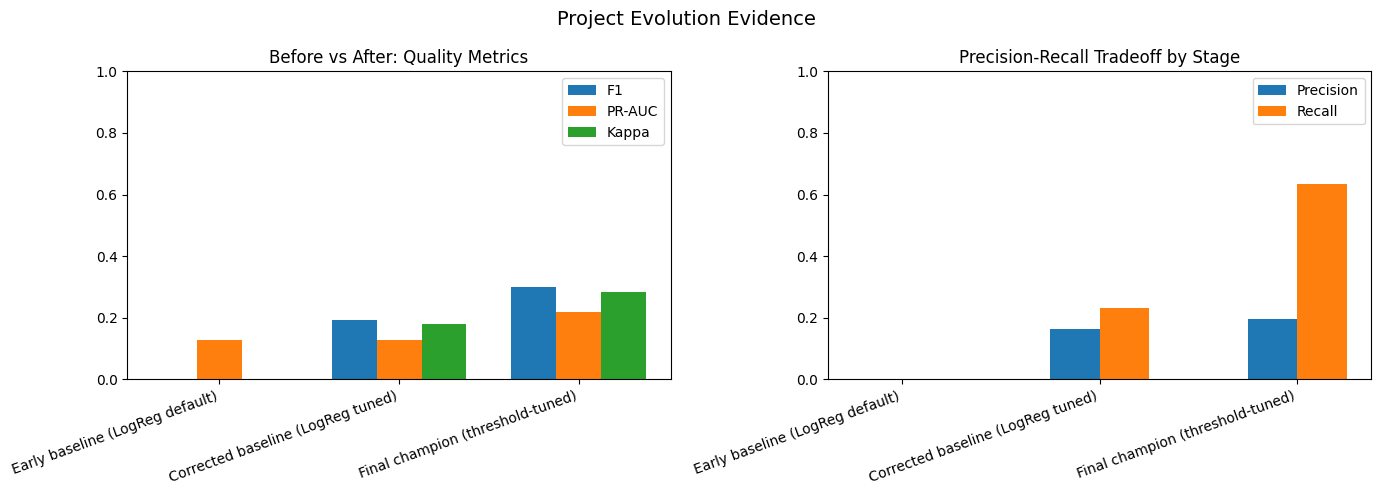

✓ Evidence table saved to reports/evolution_evidence_table.csv
✓ Evidence chart saved to reports/evolution_evidence_plot.png

Presentation evidence table:
                    model_version               model  threshold     f1  pr_auc  kappa  recall  precision
  Early baseline (LogReg default) Logistic Regression        0.5 0.0000  0.1271 0.0000  0.0000     0.0000
Corrected baseline (LogReg tuned) Logistic Regression        0.1 0.1925  0.1271 0.1793  0.2313     0.1649
 Final champion (threshold-tuned)       Random Forest        0.1 0.2993  0.2174 0.2842  0.6343     0.1959


In [14]:
import matplotlib.pyplot as plt

# Build a compact, presentation-friendly evidence table (3 rows).
stage_baseline_default = final_results[final_results['Model'] == 'Logistic Regression'].iloc[0]
stage_baseline_tuned = best_threshold_df[best_threshold_df['Model'] == 'Logistic Regression'].iloc[0]
stage_final_champion = best_threshold_df.iloc[0]

evidence_table = pd.DataFrame([
    {
        'model_version': 'Early baseline (LogReg default)',
        'model': stage_baseline_default['Model'],
        'threshold': 0.5,
        'f1': stage_baseline_default['F1'],
        'pr_auc': stage_baseline_default['PR-AUC'],
        'kappa': stage_baseline_default['Kappa'],
        'recall': stage_baseline_default['Recall'],
        'precision': stage_baseline_default['Precision'],
    },
    {
        'model_version': 'Corrected baseline (LogReg tuned)',
        'model': stage_baseline_tuned['Model'],
        'threshold': stage_baseline_tuned['Threshold'],
        'f1': stage_baseline_tuned['F1'],
        'pr_auc': stage_baseline_tuned['PR-AUC'],
        'kappa': stage_baseline_tuned['Kappa'],
        'recall': stage_baseline_tuned['Recall'],
        'precision': stage_baseline_tuned['Precision'],
    },
    {
        'model_version': 'Final champion (threshold-tuned)',
        'model': stage_final_champion['Model'],
        'threshold': stage_final_champion['Threshold'],
        'f1': stage_final_champion['F1'],
        'pr_auc': stage_final_champion['PR-AUC'],
        'kappa': stage_final_champion['Kappa'],
        'recall': stage_final_champion['Recall'],
        'precision': stage_final_champion['Precision'],
    },
])

evidence_table.to_csv('../reports/evolution_evidence_table.csv', index=False)

# Create slide-ready comparison charts.
x = np.arange(len(evidence_table))
bar_width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: outcome-quality metrics
axes[0].bar(x - bar_width, evidence_table['f1'], width=bar_width, label='F1')
axes[0].bar(x, evidence_table['pr_auc'], width=bar_width, label='PR-AUC')
axes[0].bar(x + bar_width, evidence_table['kappa'], width=bar_width, label='Kappa')
axes[0].set_title('Before vs After: Quality Metrics')
axes[0].set_xticks(x)
axes[0].set_xticklabels(evidence_table['model_version'], rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right chart: decision trade-off metrics
axes[1].bar(x - bar_width / 2, evidence_table['precision'], width=bar_width, label='Precision')
axes[1].bar(x + bar_width / 2, evidence_table['recall'], width=bar_width, label='Recall')
axes[1].set_title('Precision-Recall Tradeoff by Stage')
axes[1].set_xticks(x)
axes[1].set_xticklabels(evidence_table['model_version'], rotation=20, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()

fig.suptitle('Project Evolution Evidence', fontsize=14)
fig.tight_layout()
fig.savefig('../reports/evolution_evidence_plot.png', dpi=200, bbox_inches='tight')
plt.show()

print('✓ Evidence table saved to reports/evolution_evidence_table.csv')
print('✓ Evidence chart saved to reports/evolution_evidence_plot.png')
print('\nPresentation evidence table:')
print(evidence_table.round(4).to_string(index=False))

## 9. Result Interpretation: Curves, Confusion Tradeoffs, and Key Findings


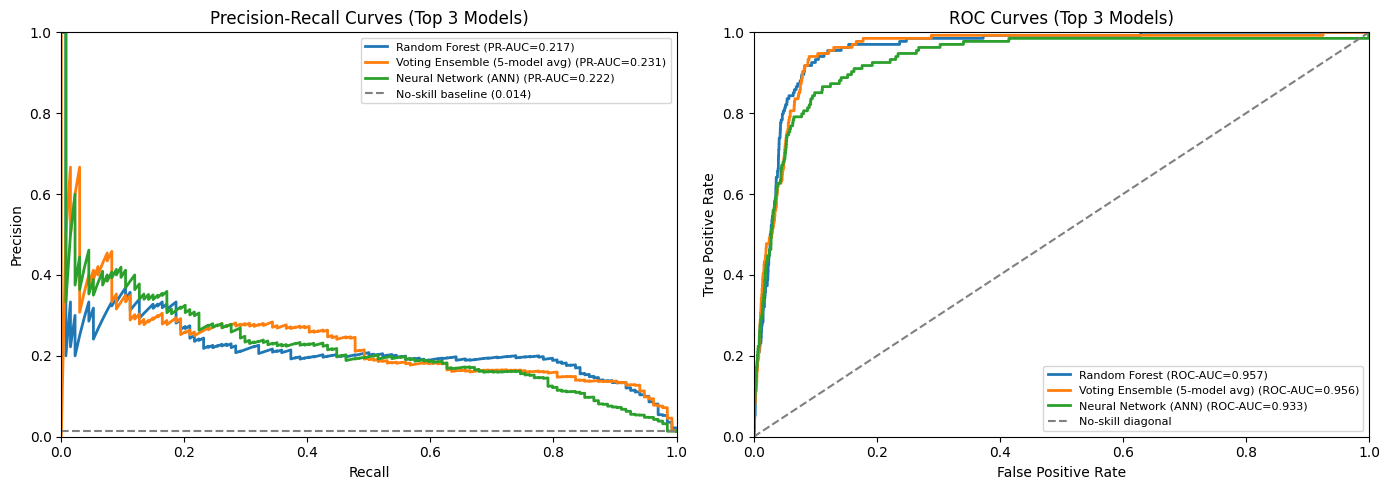

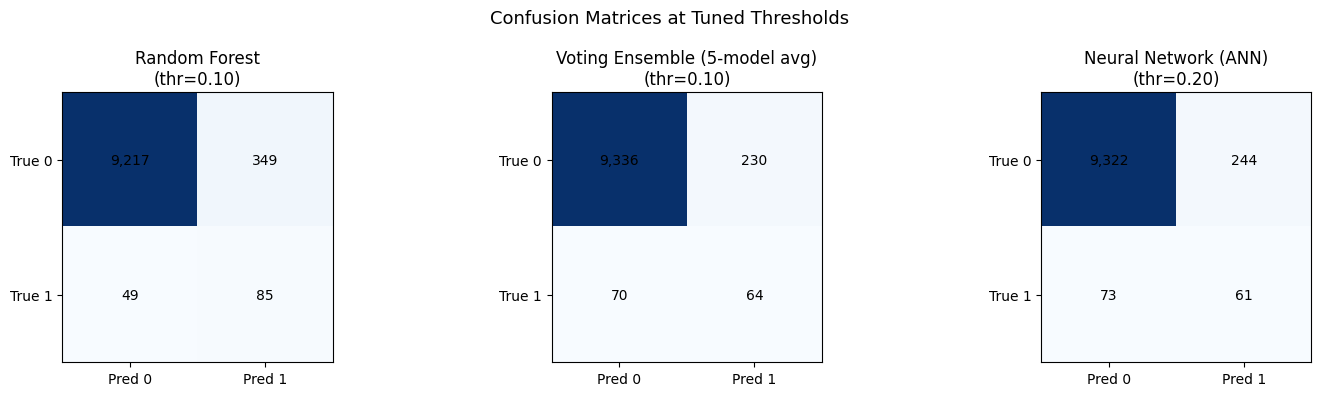

✓ Curves saved to reports/top_model_curves.png
✓ Confusion matrices saved to reports/top_model_confusion_matrices.png
✓ Interpretation summary saved to reports/results_interpretation_summary.csv

Top-model interpretation summary:
                        Model  Threshold  PR-AUC  ROC-AUC     F1  Precision  Recall  Kappa  Predicted Positive Rate  Alerts per 1000 cases  Estimated true positives per 1000
                Random Forest        0.1  0.2174   0.9574 0.2993     0.1959  0.6343 0.2842                   0.0447                   44.7                                8.8
Voting Ensemble (5-model avg)        0.1  0.2310   0.9556 0.2991     0.2177  0.4776 0.2855                   0.0303                   30.3                                6.6
         Neural Network (ANN)        0.2  0.2223   0.9335 0.2779     0.2000  0.4552 0.2638                   0.0314                   31.4                                6.3


In [15]:
# Interpretation layer for imbalanced classification: top-model curves + confusion tradeoffs.

# Select top 3 models by tuned-threshold F1.
top_models = best_threshold_df.sort_values('F1', ascending=False).head(3).copy()

# Plot PR and ROC curves for the top models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve (more informative for rare positives).
for _, row in top_models.iterrows():
    model_name = row['Model']
    y_proba = model_probabilities[model_name]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[0].plot(recall, precision, linewidth=2, label=f"{model_name} (PR-AUC={row['PR-AUC']:.3f})")

axes[0].axhline(test_prevalence, color='gray', linestyle='--', linewidth=1.5, label=f'No-skill baseline ({test_prevalence:.3f})')
axes[0].set_title('Precision-Recall Curves (Top 3 Models)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# ROC curve.
for _, row in top_models.iterrows():
    model_name = row['Model']
    y_proba = model_probabilities[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f"{model_name} (ROC-AUC={row['ROC-AUC']:.3f})")

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='No-skill diagonal')
axes[1].set_title('ROC Curves (Top 3 Models)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig('../reports/top_model_curves.png', dpi=200, bbox_inches='tight')
plt.show()

# Confusion-matrix heatmaps at each model's tuned threshold.
fig, axes = plt.subplots(1, len(top_models), figsize=(5 * len(top_models), 4))
if len(top_models) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, top_models.iterrows()):
    model_name = row['Model']
    threshold = float(row['Threshold'])
    y_pred_tuned = (model_probabilities[model_name] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned, labels=[0, 1]).ravel()

    cm = np.array([[tn, fp], [fn, tp]])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha='center', va='center', fontsize=10)

    ax.set_title(f"{model_name}\n(thr={threshold:.2f})")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])

fig.suptitle('Confusion Matrices at Tuned Thresholds', fontsize=13)
fig.tight_layout()
fig.savefig('../reports/top_model_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

# Export an interpretation summary with operational tradeoffs.
interpret_rows = []
for _, row in top_models.iterrows():
    model_name = row['Model']
    threshold = float(row['Threshold'])
    y_pred_tuned = (model_probabilities[model_name] >= threshold).astype(int)
    predicted_positive_rate = float(np.mean(y_pred_tuned))

    interpret_rows.append({
        'Model': model_name,
        'Threshold': threshold,
        'PR-AUC': float(row['PR-AUC']),
        'ROC-AUC': float(row['ROC-AUC']),
        'F1': float(row['F1']),
        'Precision': float(row['Precision']),
        'Recall': float(row['Recall']),
        'Kappa': float(row['Kappa']),
        'Predicted Positive Rate': predicted_positive_rate,
        'Alerts per 1000 cases': round(predicted_positive_rate * 1000, 1),
        'Estimated true positives per 1000': round(float(row['Recall']) * test_prevalence * 1000, 1),
    })

interpret_df = pd.DataFrame(interpret_rows).sort_values('F1', ascending=False).reset_index(drop=True)
interpret_df.to_csv('../reports/results_interpretation_summary.csv', index=False)

print('✓ Curves saved to reports/top_model_curves.png')
print('✓ Confusion matrices saved to reports/top_model_confusion_matrices.png')
print('✓ Interpretation summary saved to reports/results_interpretation_summary.csv')
print('\nTop-model interpretation summary:')
print(interpret_df.round(4).to_string(index=False))



## Summary & Next Steps

In [16]:
default_best_model = final_results.iloc[0]
threshold_best_model = best_threshold_df.iloc[0]
print('\n' + '='*90)
print('PROJECT SUMMARY')
print('='*90)
print(f"\nBest Model (Default Threshold=0.5): {default_best_model['Model']}")
print(f"  F1 Score: {default_best_model['F1']:.4f}")
print(f"  Precision: {default_best_model['Precision']:.4f}")
print(f"  Recall: {default_best_model['Recall']:.4f}")
if 'ROC-AUC' in default_best_model and pd.notna(default_best_model['ROC-AUC']):
    print(f"  ROC-AUC: {default_best_model['ROC-AUC']:.4f}")
if 'PR-AUC' in default_best_model and pd.notna(default_best_model['PR-AUC']):
    print(f"  PR-AUC: {default_best_model['PR-AUC']:.4f}")
if 'Kappa' in default_best_model and pd.notna(default_best_model['Kappa']):
    print(f"  Kappa: {default_best_model['Kappa']:.4f}")
print(f"\nChampion After Threshold Tuning: {threshold_best_model['Model']}")
print(f"  Threshold: {threshold_best_model['Threshold']:.2f}")
print(f"  F1 Score: {threshold_best_model['F1']:.4f}")
print(f"  Precision: {threshold_best_model['Precision']:.4f}")
print(f"  Recall: {threshold_best_model['Recall']:.4f}")
print(f"  Kappa: {threshold_best_model['Kappa']:.4f}")
print(f"\nModels Trained: {len(results)}")
print(f"  - 2 baseline (Logistic Regression, Naive Bayes)")
print(f"  - 1 KNN (k=5)")
print(f"  - 1 Random Forest (100 trees)")
print(f"  - 1 Neural Network (3-layer ANN)")
print(f"  - 1 Voting Ensemble (5-model soft average)")
print(f"\n✓ Model comparison complete!")
print('✓ Results in reports:')
print('  - model_comparison.csv')
print('  - model_comparison_with_ensemble.csv')
print('  - model_comparison_detailed.csv')
print('  - threshold_analysis.csv')
print('  - confusion_matrices.csv')
print('  - evolution_log.md')
print('  - top_model_curves.png')
print('  - top_model_confusion_matrices.png')
print('  - results_interpretation_summary.csv')



PROJECT SUMMARY

Best Model (Default Threshold=0.5): KNN (k=5)
  F1 Score: 0.0915
  Precision: 0.3684
  Recall: 0.0522
  ROC-AUC: 0.6397
  PR-AUC: 0.0698
  Kappa: 0.0884

Champion After Threshold Tuning: Random Forest
  Threshold: 0.10
  F1 Score: 0.2993
  Precision: 0.1959
  Recall: 0.6343
  Kappa: 0.2842

Models Trained: 6
  - 2 baseline (Logistic Regression, Naive Bayes)
  - 1 KNN (k=5)
  - 1 Random Forest (100 trees)
  - 1 Neural Network (3-layer ANN)
  - 1 Voting Ensemble (5-model soft average)

✓ Model comparison complete!
✓ Results in reports:
  - model_comparison.csv
  - model_comparison_with_ensemble.csv
  - model_comparison_detailed.csv
  - threshold_analysis.csv
  - confusion_matrices.csv
  - evolution_log.md
  - top_model_curves.png
  - top_model_confusion_matrices.png
  - results_interpretation_summary.csv
